In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/student_performance.csv')

# Display first 5 rows
df.head()

Matplotlib is building the font cache; this may take a moment.


,study_hours,attendance,sleep_hours,previous_grades,assignments_completed,internet_usage,test_scores,final_score
0,5,90,7,80,9,3,78,82
1,2,60,5,55,4,8,50,58
2,7,95,8,88,10,2,91,93
3,4,75,6,70,7,5,69,72
4,6,85,7,82,8,4,84,86


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   study_hours            8 non-null      int64
 1   attendance             8 non-null      int64
 2   sleep_hours            8 non-null      int64
 3   previous_grades        8 non-null      int64
 4   assignments_completed  8 non-null      int64
 5   internet_usage         8 non-null      int64
 6   test_scores            8 non-null      int64
 7   final_score            8 non-null      int64
dtypes: int64(8)
memory usage: 644.0 bytes


In [4]:
# Check missing values
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
previous_grades          0
assignments_completed    0
internet_usage           0
test_scores              0
final_score              0
dtype: int64

In [5]:
# Statistical summary
df.describe()

,study_hours,attendance,sleep_hours,previous_grades,assignments_completed,internet_usage,test_scores,final_score
count,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,4.50000,77.250000,6.250000,71.500000,7.000000,4.875000,70.625000,74.625000
std,2.44949,17.580427,1.488048,16.835337,2.725541,2.900123,19.884937,17.727602
min,1.00000,50.000000,4.000000,45.000000,3.000000,1.000000,40.000000,48.000000
25%,2.75000,63.750000,5.000000,58.750000,4.750000,2.750000,56.000000,60.250000
50%,4.50000,80.000000,6.500000,75.000000,7.500000,4.500000,73.500000,77.000000
75%,6.25000,91.250000,7.250000,83.500000,9.250000,7.250000,85.750000,87.750000
max,8.00000,98.000000,8.000000,92.000000,10.000000,9.000000,95.000000,97.000000


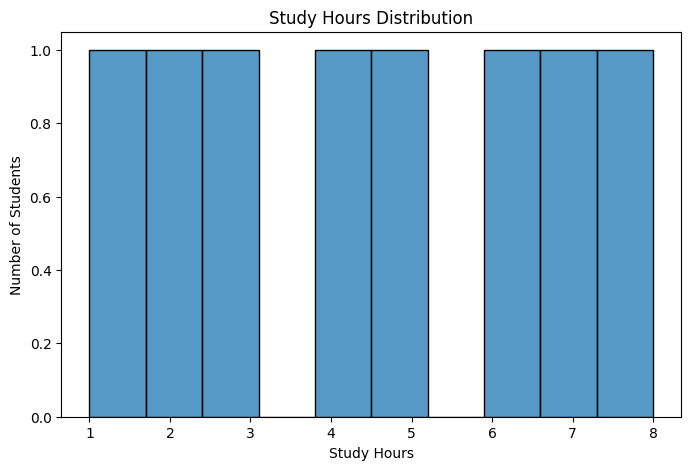

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['study_hours'], bins=10)

plt.title('Study Hours Distribution')
plt.xlabel('Study Hours')
plt.ylabel('Number of Students')

plt.show()

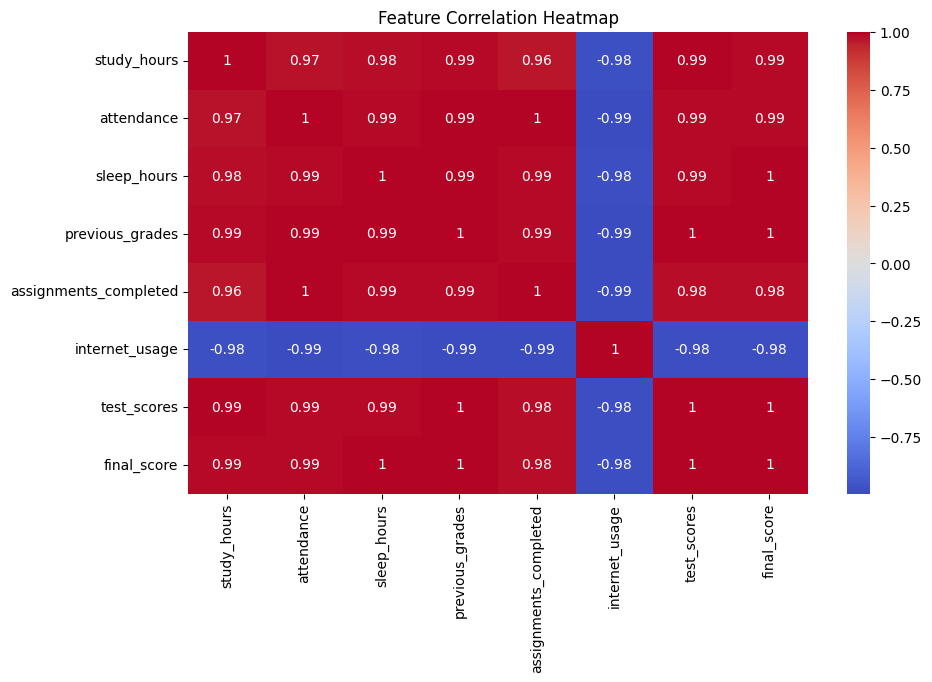

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')

plt.show()

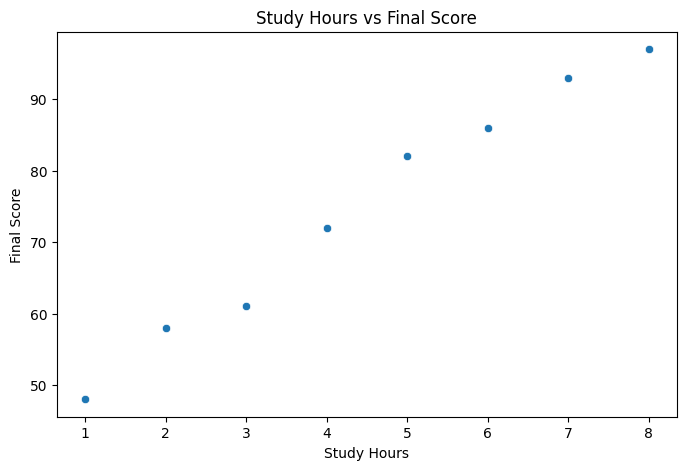

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['study_hours'],
    y=df['final_score']
)

plt.title('Study Hours vs Final Score')
plt.xlabel('Study Hours')
plt.ylabel('Final Score')

plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Features (inputs)
X = df.drop('final_score', axis=1)

# Target (output)
y = df['final_score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (6, 7)
Testing Data Shape: (2, 7)


In [10]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

print("Predicted Scores:")
print(lr_predictions)

Predicted Scores:
[57.53294122 63.96348362]


In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Evaluate model
mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 1.7152712020783163
MSE: 4.500189545604262
R² Score: -1.0000842424907832


In [12]:
import random
import pandas as pd

data = []

for i in range(300):

    study_hours = random.randint(1, 10)
    attendance = random.randint(50, 100)
    sleep_hours = random.randint(4, 9)
    previous_grades = random.randint(40, 95)
    assignments_completed = random.randint(1, 10)
    internet_usage = random.randint(1, 10)
    test_scores = random.randint(40, 100)

    # Generate realistic final score
    final_score = (
        study_hours * 2
        + attendance * 0.2
        + sleep_hours * 1.5
        + previous_grades * 0.3
        + assignments_completed * 2
        - internet_usage * 1.5
        + test_scores * 0.4
    )

    final_score = round(final_score)

    data.append([
        study_hours,
        attendance,
        sleep_hours,
        previous_grades,
        assignments_completed,
        internet_usage,
        test_scores,
        final_score
    ])

# Create DataFrame
df_large = pd.DataFrame(data, columns=[
    'study_hours',
    'attendance',
    'sleep_hours',
    'previous_grades',
    'assignments_completed',
    'internet_usage',
    'test_scores',
    'final_score'
])

# Save dataset
df_large.to_csv('../data/student_performance.csv', index=False)

print("Dataset Created Successfully!")
print(df_large.head())

Dataset Created Successfully!
   study_hours  attendance  sleep_hours  previous_grades  \
0           10          87            8               83   
1            6          78            9               51   
2            1          85            5               60   
3            2          51            4               60   
4            3          77            7               52   

   assignments_completed  internet_usage  test_scores  final_score  
0                      4               8           43           88  
1                      9               1           68          100  
2                      1               7           76           66  
3                      4               6           48           56  
4                      3               6           93           82  


In [13]:
# Reload updated dataset
df = pd.read_csv('../data/student_performance.csv')

# Check dataset size
print(df.shape)

# Show first 5 rows
df.head()

(300, 8)


,study_hours,attendance,sleep_hours,previous_grades,assignments_completed,internet_usage,test_scores,final_score
0,10,87,8,83,4,8,43,88
1,6,78,9,51,9,1,68,100
2,1,85,5,60,1,7,76,66
3,2,51,4,60,4,6,48,56
4,3,77,7,52,3,6,93,82


In [14]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop('final_score', axis=1)

# Target
y = df['final_score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (240, 7)
Testing Shape: (60, 7)


In [15]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

print(lr_predictions[:10])

[ 69.92585774  74.39076479  76.1244224   83.06879916  98.38714613
  96.87348176  81.13435033  79.54709766  93.18033026 105.15037289]


In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Evaluation
mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 0.22907066792541228
MSE: 0.07767620442078607
R² Score: 0.9995511602656837


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:10])

[74.14 82.79 79.   81.94 92.15 89.03 81.3  81.19 96.56 97.25]


In [18]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 4.650833333333334
Random Forest MSE: 33.441798333333324
Random Forest R² Score: 0.8067618263415386


In [19]:
# Feature Importance

importance = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

                 Feature  Importance
6            test_scores    0.328459
4  assignments_completed    0.215469
3        previous_grades    0.158503
0            study_hours    0.128899
5         internet_usage    0.092184
1             attendance    0.043918
2            sleep_hours    0.032567


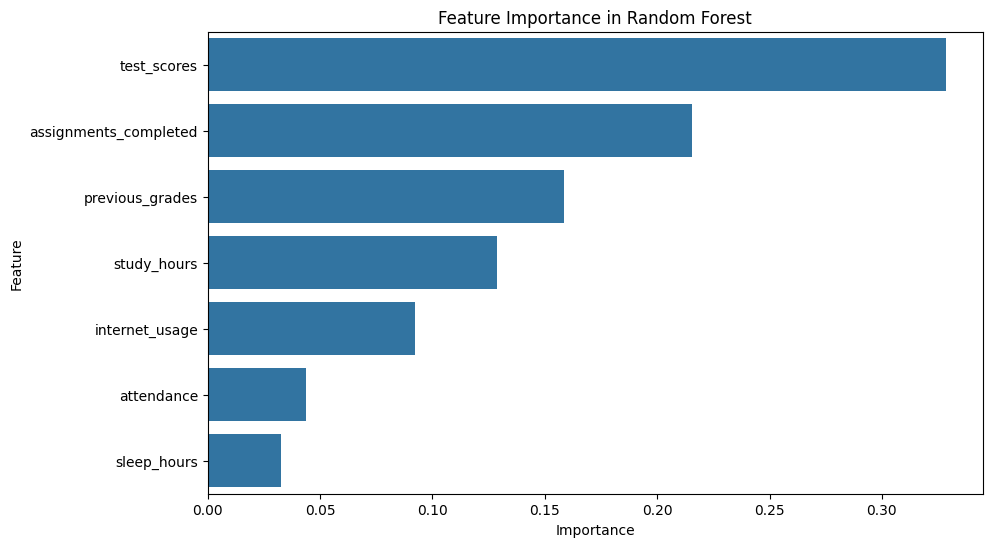

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Feature Importance in Random Forest')

plt.show()

# Final Project Insights

1. Test scores are the strongest predictor of final academic performance.

2. Students completing more assignments generally achieve higher scores.

3. Previous grades strongly influence future academic performance.

4. Study hours positively affect final marks.

5. Excessive internet usage negatively impacts performance.

6. Balanced sleep contributes moderately to academic success.

7. Linear Regression performed better than Random Forest because the generated dataset follows mostly linear relationships.